Merging all model results...

--- FINAL MODEL PERFORMANCE RANKING ---
             Model  AUPRC (Primary)  ROC-AUC Min Cost/Tx  Optimal Threshold
               lgb         0.533154 0.917266       $1.46               0.04
               xgb         0.517012 0.899501       $1.72               0.02
          mlp_prob         0.366416 0.856659       $1.93               0.00
               iso         0.098818 0.769716       $1.93               0.00
ae_semi_supervised         0.066107 0.710960       $1.93               0.00
     ae_supervised         0.064430 0.707859       $1.93               0.00
               lof         0.040552 0.550710       $1.93               0.00

Error analysis completed for lgb.
Files saved: 'final_pr_curves.png', 'final_model_comparison_table.csv', 'top_10_false_positives.csv', 'top_10_false_negatives.csv'


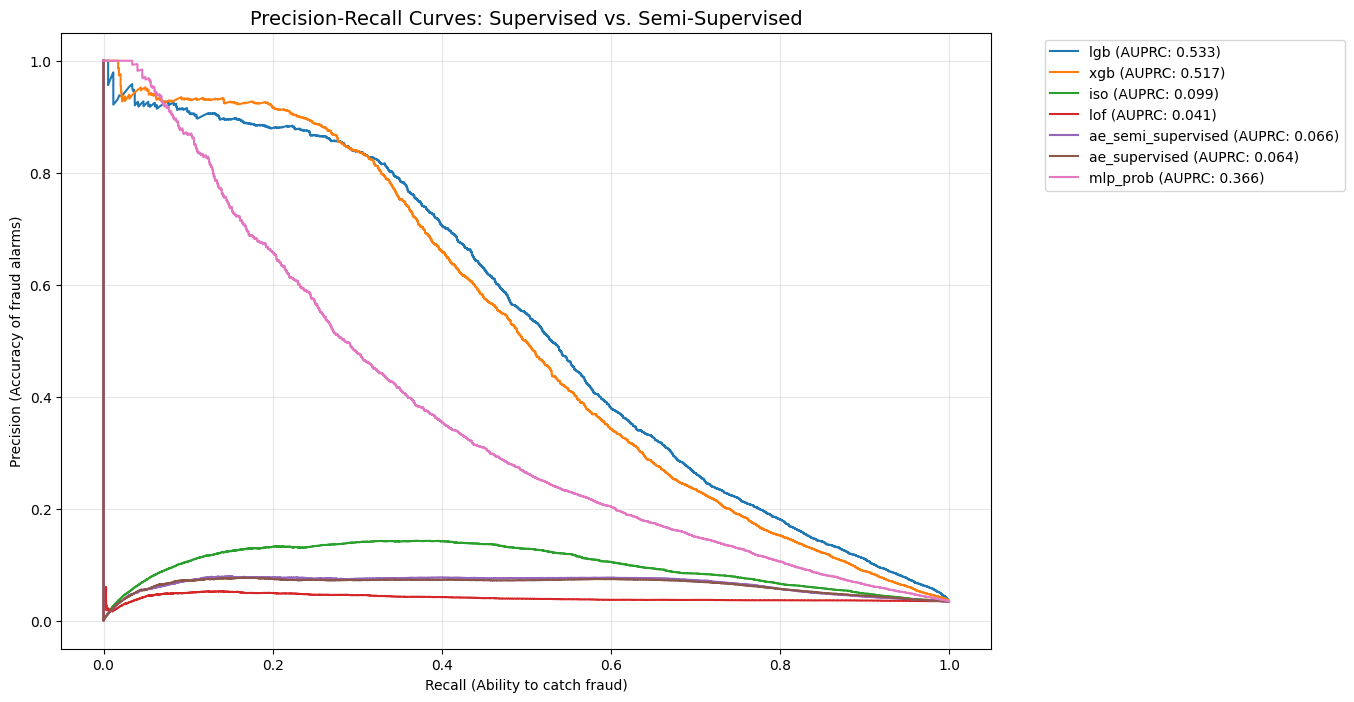

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_recall_curve, average_precision_score, roc_auc_score, confusion_matrix

# 1. LOAD AND MERGE
print("Merging all model results...")
ml_df = pd.read_csv('results/all_ml_probs.csv')
dl_df = pd.read_csv('results/dl_results.csv')
impact_df = pd.read_csv('results/feature_impact_results.csv')

# Combine into one master dataframe 
df = pd.concat([ml_df, dl_df.drop('actual', axis=1)], axis=1)

# Identify models (exclude the target)
models = [col for col in df.columns if col != 'actual']

# 2. COST-SENSITIVE EVALUATION ($500 FN vs $2 FP)
def calculate_business_cost(y_true, y_prob):
    thresholds = np.linspace(0, 1, 101)
    costs = []
    for t in thresholds:
        y_pred = (y_prob >= t).astype(int)
        fn = ((y_true == 1) & (y_pred == 0)).sum()
        fp = ((y_true == 0) & (y_pred == 1)).sum()
        # Total cost logic from rubric
        total_cost = (fn * 500) + (fp * 2)
        costs.append(total_cost / len(y_true)) 
    return thresholds, costs

# 3. GENERATE SUMMARY PERFORMANCE TABLE
summary_stats = []
plt.figure(figsize=(12, 8))

for m in models:
    # Autoencoder and Isolation Forest scores often need inversion if they represent "outlierness" 
    # but here we treat high = more likely fraud
    y_prob = df[m]
    
    # Standardize score ranges for metrics if necessary
    if y_prob.max() > 1.0 or y_prob.min() < 0:
        y_prob = (y_prob - y_prob.min()) / (y_prob.max() - y_prob.min())
    
    aup_score = average_precision_score(df['actual'], y_prob)
    auc_score = roc_auc_score(df['actual'], y_prob)
    
    # Calculate optimal business cost
    thresh, costs = calculate_business_cost(df['actual'], y_prob)
    min_cost = np.min(costs)
    opt_thresh = thresh[np.argmin(costs)]
    
    summary_stats.append({
        'Model': m,
        'AUPRC (Primary)': aup_score,
        'ROC-AUC': auc_score,
        'Min Cost/Tx': f"${min_cost:.2f}",
        'Optimal Threshold': opt_thresh
    })
    
    # Plot PR Curve
    precision, recall, _ = precision_recall_curve(df['actual'], y_prob)
    plt.plot(recall, precision, label=f'{m} (AUPRC: {aup_score:.3f})')

# Formatting the PR Curve
plt.title('Precision-Recall Curves: Supervised vs. Semi-Supervised', fontsize=14)
plt.xlabel('Recall (Ability to catch fraud)')
plt.ylabel('Precision (Accuracy of fraud alarms)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(alpha=0.3)
plt.savefig('report/final_pr_curves.png', bbox_inches='tight')

# 4. SHOW FINAL TABLE
results_table = pd.DataFrame(summary_stats).sort_values(by='AUPRC (Primary)', ascending=False)
print("\n--- FINAL MODEL PERFORMANCE RANKING ---")
print(results_table.to_string(index=False))
results_table.to_csv('report/final_model_comparison_table.csv', index=False)

# 5. CONFIDENT ERROR ANALYSIS (Manual Review)
# We use the top-performing model (likely LightGBM or MLP)
best_model_name = results_table.iloc[0]['Model']
df['prob'] = df[best_model_name]

# Confident False Positives: Model is 90%+ sure it's fraud, but it's not.
false_positives = df[(df['actual'] == 0)].sort_values(by='prob', ascending=False).head(10)

# Confident False Negatives: Model is 90%+ sure it's NOT fraud, but it is.
false_negatives = df[(df['actual'] == 1)].sort_values(by='prob', ascending=True).head(10)

false_positives.to_csv('report/top_10_false_positives.csv')
false_negatives.to_csv('report/top_10_false_negatives.csv')

print(f"\nError analysis completed for {best_model_name}.")
print("Files saved: 'final_pr_curves.png', 'final_model_comparison_table.csv', 'top_10_false_positives.csv', 'top_10_false_negatives.csv'")